In [1]:
# imports 
import numpy as np
import pandas as pd 
from scipy.stats import sem, ttest_rel, pearsonr, ttest_1samp, shapiro, levene, wilcoxon
from matplotlib import pyplot as plt

from functions import convert_to_deg, check_normality, human_reliability

Figure 2 B

In [2]:
# load the human data 
s5x = np.load('data/s5x.npy')
s5y = np.load('data/s5y.npy')
s3x = np.load('data/s3x.npy')
s3y = np.load('data/s3y.npy')
s4x = np.load('data/s4x.npy')
s4y = np.load('data/s4y.npy')

In [3]:
# Convert the estimates to eccintricity space (i.e., degrees of visual angle)
human_im_size = 268.51895786308

s5x = convert_to_deg(s5x, human_im_size)
s3x = convert_to_deg(s3x, human_im_size)
s4x = convert_to_deg(s4x, human_im_size)

s5y = convert_to_deg(s5y, human_im_size)
s3y = convert_to_deg(s3y, human_im_size)
s4y = convert_to_deg(s4y, human_im_size)

In [4]:
# load the ground truth center positions in pixel space 
gt_im_size = 256
df = pd.read_csv('data/mae_s5_coordinates.csv') # position data
xpos = np.squeeze(df['center_x'].values.reshape(-1,1))*(human_im_size/gt_im_size) # convert to the dimensions of the image that the humans made estimates on
ypos = np.squeeze(df['center_y'].values.reshape(-1,1))*(human_im_size/gt_im_size)

# convert to ecc 
xpos = convert_to_deg(xpos, human_im_size)
ypos = convert_to_deg(ypos, human_im_size)

In [5]:
# mean data across participants 
mean_s5x = np.nanmean(s5x,axis=1)
std_s5x = np.nanstd(s5x,axis=1)
sem_s5x = sem(s5x,axis=1)

mean_s5y = np.nanmean(s5y,axis=1)
std_s5y = np.nanstd(s5y,axis=1)

mean_s3x = np.nanmean(s3x,axis=1)
std_s3x = np.nanstd(s3x,axis=1)
sem_s3x = sem(s3x,axis=1)

mean_s3y = np.nanmean(s3y,axis=1)
std_s3y = np.nanstd(s3y,axis=1)

mean_s4x = np.nanmean(s4x,axis=1)
std_s4x = np.nanstd(s4x,axis=1)
sem_s4x = sem(s4x,axis=1)

mean_s4y = np.nanmean(s4y,axis=1)
std_s4y = np.nanstd(s4y,axis=1)

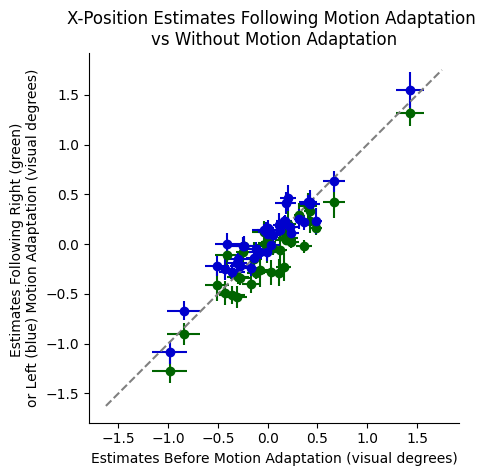

In [6]:
# estimates before and after motion adaptation for both directions 
pos_rangex = np.linspace(min(xpos),max(xpos))

plt.errorbar(mean_s5x,mean_s3x,yerr=sem_s3x,xerr=sem_s5x,fmt='o',color='darkgreen',label='Rightward Adapter')
plt.errorbar(mean_s5x,mean_s4x,yerr=sem_s4x,xerr=sem_s5x,fmt='o',color='mediumblue',label='Leftward Adapter')
plt.plot(pos_rangex,pos_rangex,color='grey',linestyle='--')
plt.title('X-Position Estimates Following Motion Adaptation \nvs Without Motion Adaptation')
plt.xlabel('Estimates Before Motion Adaptation (visual degrees)')
plt.ylabel('Estimates Following Right (green) \nor Left (blue) Motion Adaptation (visual degrees)')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
x0, x1 = plt.gca().get_xlim()
y0, y1 = plt.gca().get_ylim()
plt.gca().set_aspect(abs(x1 - x0) / abs(y1 - y0)) 

# plt.savefig('/home/eyakub/scratch/scatter.eps', format='eps', bbox_inches='tight')

Figure 2 C

In [7]:
# check whether we can use a parametric test
print(f"s5x vs s3x: {check_normality('pairedt', mean_s5x,mean_s3x)}")
print(f"s5x vs s4x: {check_normality('pairedt', mean_s5x,mean_s4x)}")

# printed values are p-values, greater than 0.05 => can use parametric tests

s5x vs s3x: 0.6652313470840454
s5x vs s4x: 0.9994473457336426


In [8]:
# run the tests 
print(f"s5x vs s3x: {ttest_rel(mean_s5x,mean_s3x)}")
print(f"s5x vs s4x: {ttest_rel(mean_s5x,mean_s4x)}")

s5x vs s3x: TtestResult(statistic=3.9099242058645993, pvalue=0.0003581428093441211, df=39)
s5x vs s4x: TtestResult(statistic=-3.103457540646357, pvalue=0.003551403369165934, df=39)


In [9]:
# get the average deltas
mean_deltax = np.nanmean(mean_s4x - mean_s3x)
sem_deltax = sem(mean_s4x - mean_s3x)

mean_deltay = np.nanmean(mean_s4y - mean_s3y)
sem_deltay = sem(mean_s4y - mean_s3y)

mean_s3deltax = np.nanmean(mean_s3x-mean_s5x)
sem_s3deltax = sem(mean_s3x-mean_s5x)

mean_s3deltay = np.nanmean(mean_s3y-mean_s5y)
sem_s3deltay = sem(mean_s3y-mean_s5y)

mean_s4deltax = np.nanmean(mean_s4x-mean_s5x)
sem_s4deltax = sem(mean_s4x-mean_s5x)

mean_s4deltay = np.nanmean(mean_s4y-mean_s5y)
sem_s4deltay = sem(mean_s4y-mean_s5y)

In [10]:
# check assumptions for single sample t-test 
print(f"s3-s5: {check_normality('singlet',mean_s3x-mean_s5x)}")
print(f"s4-s5: {check_normality('singlet',mean_s4x-mean_s5x)}")

s3-s5: 0.6652313470840454
s4-s5: 0.9994473457336426


In [11]:
# assumptions are not violated so we do single sample t-test
print(f"s3-s5: {ttest_1samp(mean_s3x-mean_s5x,0)}")
print(f"s4-s5: {ttest_1samp(mean_s4x-mean_s5x,0)}")

s3-s5: TtestResult(statistic=-3.9099242058645993, pvalue=0.0003581428093441211, df=39)
s4-s5: TtestResult(statistic=3.103457540646357, pvalue=0.003551403369165934, df=39)


In [12]:
# check assumptions for single sample t-test - y axis deltas 
print(f"s3-s5: {check_normality('singlet',mean_s3y-mean_s5y)}")
print(f"s4-s5: {check_normality('singlet',mean_s4y-mean_s5y)}")

s3-s5: 0.7717539072036743
s4-s5: 0.7008213400840759


In [13]:
# assumptions are not violated so we do single sample t-test
print(f"s3-s5: {ttest_1samp(mean_s3y-mean_s5y,0)}")
print(f"s4-s5: {ttest_1samp(mean_s4y-mean_s5y,0)}")

s3-s5: TtestResult(statistic=0.4997518777475686, pvalue=0.620057812202792, df=39)
s4-s5: TtestResult(statistic=-0.1842357277585319, pvalue=0.854783181360908, df=39)


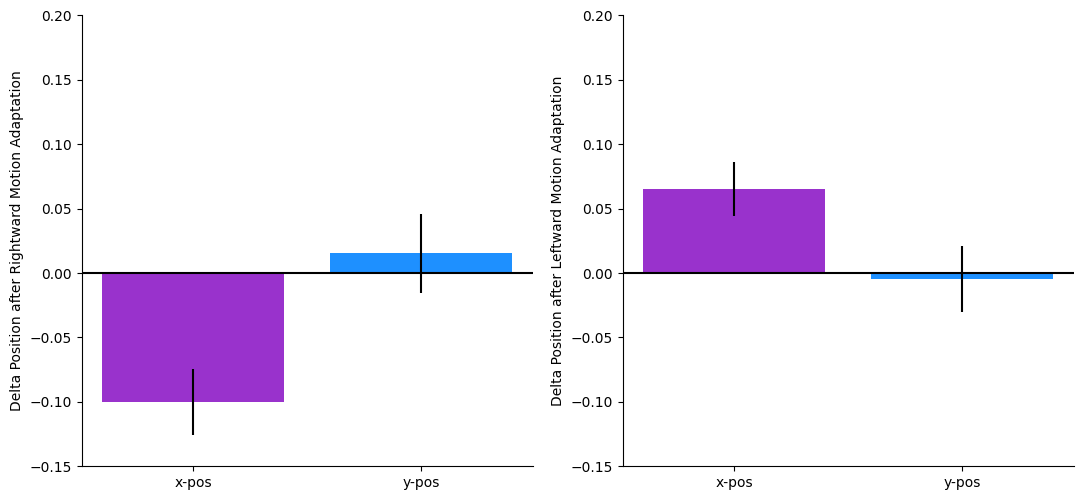

In [14]:
# plot the average deltas for both x and y 
fig2,axs2 = plt.subplots(1,2)

current_size = fig2.get_size_inches() 
fig2.set_size_inches(current_size[0] * 2, current_size[1] * 2)

axs2[0].bar(['x-pos','y-pos'],[mean_s3deltax,mean_s3deltay],yerr=[sem_s3deltax,sem_s3deltay],color=['darkorchid','dodgerblue'])
axs2[0].set_ylabel('Delta Position after Rightward Motion Adaptation')

axs2[1].bar(['x-pos','y-pos'],[mean_s4deltax,mean_s4deltay],yerr=[sem_s4deltax,sem_s4deltay],color=['darkorchid','dodgerblue'])
axs2[1].set_ylabel('Delta Position after Leftward Motion Adaptation')

for n in range(2):
    axs2[n].axhline(y=0,color='black')
    axs2[n].spines['top'].set_visible(False)
    axs2[n].spines['right'].set_visible(False)
    axs2[n].set_ylim(-0.15,0.2)
    x0, x1 = axs2[n].get_xlim()
    y0, y1 = axs2[n].get_ylim()
    axs2[n].set_aspect(abs(x1 - x0) / abs(y1 - y0)) 


# plt.savefig('/home/eyakub/scratch/human_deltas.eps', format='eps', bbox_inches='tight')

Figure 2 D

In [15]:
# get split-half reliabilities of human estimates across trials 
x_rels = [1]
y_rels = [1]

mean_x_rels = []
mean_y_rels = []

x_stds = []
y_stds = []

x_data = [s5x,s3x,s4x]
y_data = [s5y,s3y,s4y]

for i in range(3):
    x_rel_array, x_rel, x_std = human_reliability(x_data[i])
    y_rel_array, y_rel, y_std = human_reliability(y_data[i])
    
    x_rels.append(x_rel_array)
    mean_x_rels.append(x_rel)
    x_stds.append(x_std)
    y_rels.append(y_rel_array)
    mean_y_rels.append(y_rel)
    y_stds.append(y_std)

In [16]:
# define a function to get corrected correlations and the ceiling 
def get_corr(a,b,rel_a,rel_b):
    '''
    A function to compute the correlation between two data vectors of equal length corrected by split-half reliability  and ceiling for correlation between 
    any two data vectors of equal size.
    a - ndarray[n]
    b - ndarray[n]
    rel_a - ndarray[n_reps] split-half reliability of a, computed over n_reps shuffles of splitting halves
    rel_b - ndarray[n_reps]
    '''
    
    # correlation
    r = pearsonr(a,b)[0]
    cl_ints = pearsonr(a,b).confidence_interval() # get confidence intervals using Fisher transformation 
    cl = cl_ints[1] - cl_ints[0] # specify the length of the errorbar as the difference between top and bottom intervals 

    # celing
    ceiling = (rel_a*rel_b)**0.5
    mean_ceiling = np.nanmean(ceiling)
    std_ceiling = np.nanstd(ceiling)

    return [r, cl, mean_ceiling, std_ceiling] # the version for plotting the non-corrected correlation against its ceiling

In [17]:
# get correlations for all combinations 
x_data = [xpos,mean_s5x,mean_s3x,mean_s4x]
y_data = [ypos,mean_s5y,mean_s3y,mean_s4y]

all_data = [x_data,y_data]
all_rels = [x_rels,y_rels]

axis = ['x','y']
season = ['gt','s5','s3','s4']

corr_dict = {}

for x in range(len(axis)):
    data = all_data[x]
    rels = all_rels[x]
    for s in range(len(season)):
        i = s + 1
        while i < 4: # logic to make sure that each season is only correlated with every other season once 
            corr_results = get_corr(data[s],data[i],rels[s],rels[i])
            corr_dict[f"{season[s]}{axis[x]}_{season[i]}{axis[x]}"] = corr_results
            i += 1

In [19]:
corr_dict.keys()

dict_keys(['gtx_s5x', 'gtx_s3x', 'gtx_s4x', 's5x_s3x', 's5x_s4x', 's3x_s4x', 'gty_s5y', 'gty_s3y', 'gty_s4y', 's5y_s3y', 's5y_s4y', 's3y_s4y'])

/tmp/ipykernel_452791/418042260.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs2[0].set_xticklabels(labels,rotation=45)
/tmp/ipykernel_452791/418042260.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs2[1].set_xticklabels(labels,rotation=45)


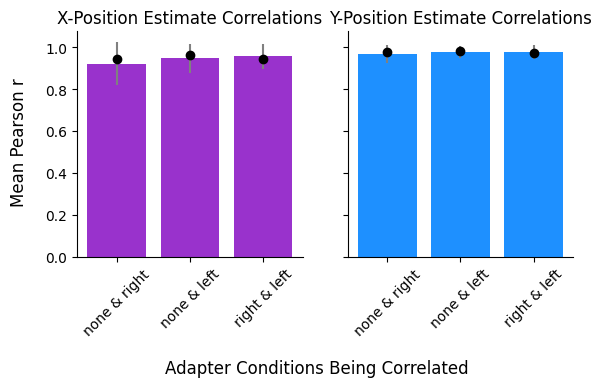

In [22]:
# plot the correlations 
x_corrs = [corr_dict['s5x_s3x'][0],corr_dict['s5x_s4x'][0],corr_dict['s3x_s4x'][0]]
y_corrs = [corr_dict['s5y_s3y'][0],corr_dict['s5y_s4y'][0],corr_dict['s3y_s4y'][0]]

x_corr_errs = [corr_dict['s5x_s3x'][1],corr_dict['s5x_s4x'][1],corr_dict['s3x_s4x'][1]]
y_corr_errs = [corr_dict['s5y_s3y'][1],corr_dict['s5y_s4y'][1],corr_dict['s3y_s4y'][1]]

x_ceiling = [corr_dict['s5x_s3x'][2],corr_dict['s5x_s4x'][2],corr_dict['s3x_s4x'][2]]
y_ceiling = [corr_dict['s5y_s3y'][2],corr_dict['s5y_s4y'][2],corr_dict['s3y_s4y'][2]]

x_ceiling_error = [corr_dict['s5x_s3x'][3],corr_dict['s5x_s4x'][3],corr_dict['s3x_s4x'][3]]
y_ceiling_error = [corr_dict['s5y_s3y'][3],corr_dict['s5y_s4y'][3],corr_dict['s3y_s4y'][3]]

labels = ['none & right', 'none & left', 'right & left']

fig2,axs2 = plt.subplots(1,2,sharey=True)

fig2.supylabel('Mean Pearson r')
fig2.supxlabel('Adapter Conditions Being Correlated')

axs2[0].bar(labels,x_corrs,yerr=x_corr_errs,color='darkorchid',ecolor='grey',zorder=2)
axs2[0].errorbar(labels,x_ceiling,yerr=x_ceiling_error,fmt='o',color='black',zorder=3)
axs2[0].set(title='X-Position Estimate Correlations')
axs2[0].set_xticklabels(labels,rotation=45)


axs2[1].bar(labels,y_corrs,yerr=y_corr_errs,color='dodgerblue',ecolor='grey',zorder=2)
axs2[1].errorbar(labels,y_ceiling,yerr=y_ceiling_error,fmt='o',color='black')
axs2[1].set(title='Y-Position Estimate Correlations')
axs2[1].set_xticklabels(labels,rotation=45)

for n in range(2):
    axs2[n].spines['top'].set_visible(False)
    axs2[n].spines['right'].set_visible(False)
    x0, x1 = axs2[n].get_xlim()
    y0, y1 = axs2[n].get_ylim()
    axs2[n].set_aspect(abs(x1 - x0) / abs(y1 - y0)) 